## Mission 4: Predicting House Price with Multiple Linear Regression

Introduction
In this mission, you will be working with a real estate dataset to perform Exploratory Data Analysis (EDA) and create a Multiple Linear Regression (MLR) model to predict the Price of a house based on various features such as Square Feet, Number of Bedrooms, Number of Bathrooms, and other factors.

The dataset includes the following columns:

**Square_Feet:** The total area of the house in square feet.

**Num_Bedrooms:** The number of bedrooms in the house.

**Num_Bathrooms:** The number of bathrooms in the house.

**Num_Floors:** The number of floors in the house.

**Garage_Size:** The size of the garage.

**Location_Score:** A score representing the desirability of the location.

**Distance_to_Center:** The distance (in km) to the city center.

**Price:** The price of the house (target variable).


**Task 1.1. &  Task 1.2. Load the dataset into a Pandas DataFrame from the CSV file stored in Blob Storage. Name the dataframe as df_house_price**
**Task 1.3. Display the first few rows.**

In [6]:
import pandas as pd
from azure.storage.blob import BlobServiceClient
from io import StringIO

blob_service_client = BlobServiceClient.from_connection_string(connection_str)
connection_str = "<YOUR_CONNECTION_STRING>"
container_name = "businesscases"
blob_name = "house_sales_prediction.csv"

blob_service_client = BlobServiceClient.from_connection_string(connection_str)

container_client = blob_service_client.get_container_client(container_name)

blob_client = container_client.get_blob_client(blob_name)

blob_data = blob_client.download_blob()
csv_content = blob_data.readall().decode('utf-8')

df_house_price = pd.read_csv(StringIO(csv_content))

display(df_house_price.head())


**Task 1.4. Check the data types and null values.**

In [7]:
import pandas as pd
df_house_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Square_Feet         500 non-null    float64
 1   Num_Bedrooms        500 non-null    int64  
 2   Num_Bathrooms       500 non-null    int64  
 3   Num_Floors          500 non-null    int64  
 4   Garage_Size         500 non-null    int64  
 5   Location_Score      500 non-null    float64
 6   Distance_to_Center  500 non-null    float64
 7   Price               500 non-null    float64
dtypes: float64(4), int64(4)
memory usage: 31.4 KB


In [8]:
print(df_house_price.isnull().sum())
print(df_house_price.dtypes)

Square_Feet           0
Num_Bedrooms          0
Num_Bathrooms         0
Num_Floors            0
Garage_Size           0
Location_Score        0
Distance_to_Center    0
Price                 0
dtype: int64
Square_Feet           float64
Num_Bedrooms            int64
Num_Bathrooms           int64
Num_Floors              int64
Garage_Size             int64
Location_Score        float64
Distance_to_Center    float64
Price                 float64
dtype: object


## Step 2: Exploratory Data Analysis (EDA)

In this step, you will perform some basic EDA to understand the relationships between the features and the target variable (Price). This includes visualising the data, checking for correlations, and identifying patterns.

Tasks:

Task 2.1. Check summary statistics for the dataset.

Task 2.2. Visualise the relationship between Square Feet and Price using a scatter plot.

Task 2.3.  Visualise the distribution of the Price variable using a histogram.

Task 2.4.  Compute and visualize the correlation matrix between the features.

**Task 2.1. Check summary statistics for the dataset.**

In [9]:
summary_stats = df_house_price.describe
print(f"summary statistics:\n{summary_stats}")

summary statistics:
<bound method NDFrame.describe of      Square_Feet  Num_Bedrooms  Num_Bathrooms  Num_Floors  Garage_Size  \
0     143.635030             1              3           3           48   
1     287.678577             1              2           1           37   
2     232.998485             1              3           2           14   
3     199.664621             5              2           2           17   
4      89.004660             4              3           3           34   
..           ...           ...            ...         ...          ...   
495   138.338057             2              2           2           16   
496   195.914028             2              3           1           45   
497    69.433659             1              1           2           18   
498   293.598702             5              1           3           41   
499   296.552686             4              3           1           20   

     Location_Score  Distance_to_Center        Price  
0 

**Task 2.2 Visualise the relationship between Square Feet and Price using a scatter plot.**

In [10]:
!pip install seaborn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 10.3 MB/s eta 0:00:00


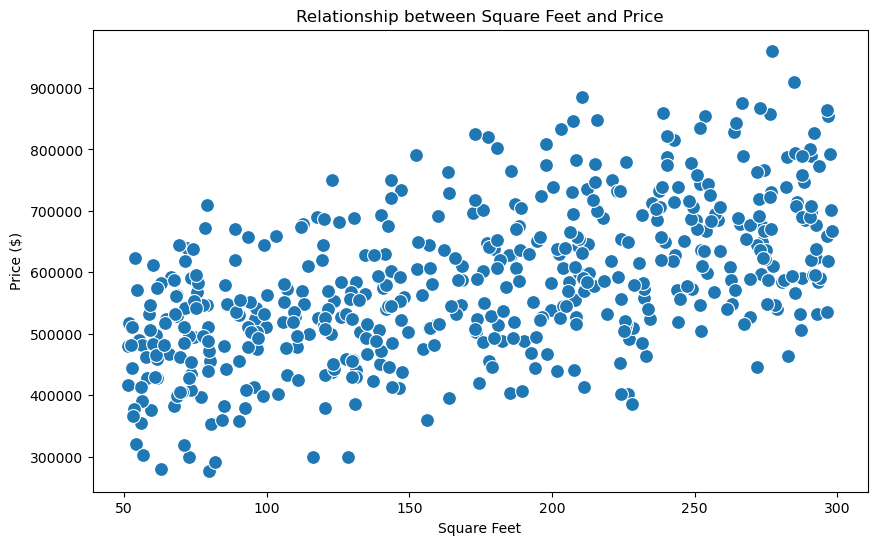

In [11]:

import seaborn as sns
import matplotlib.pyplot as plt


# Creating the scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Square_Feet', y='Price', s=100, data=df_house_price)

plt.title('Relationship between Square Feet and Price')
plt.xlabel('Square Feet')
plt.ylabel('Price ($)')

plt.show()

**Task 2.3. Visualise the distribution of the Price variable using a histogram.******

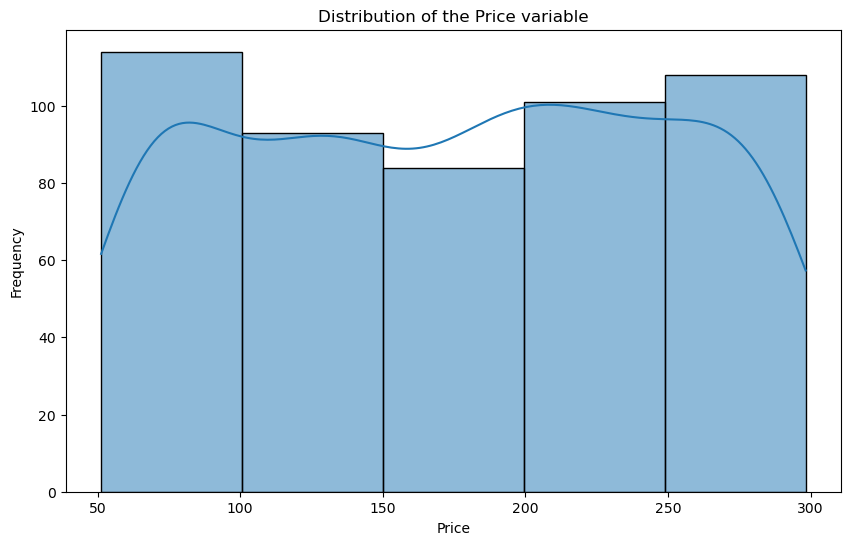

In [12]:
plt.figure(figsize=(10,6))
sns.histplot(df_house_price['Square_Feet'], bins=5, kde=True)
plt.title('Distribution of the Price variable')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

****Task 2.4. Compute and visualize the correlation matrix between the features.**

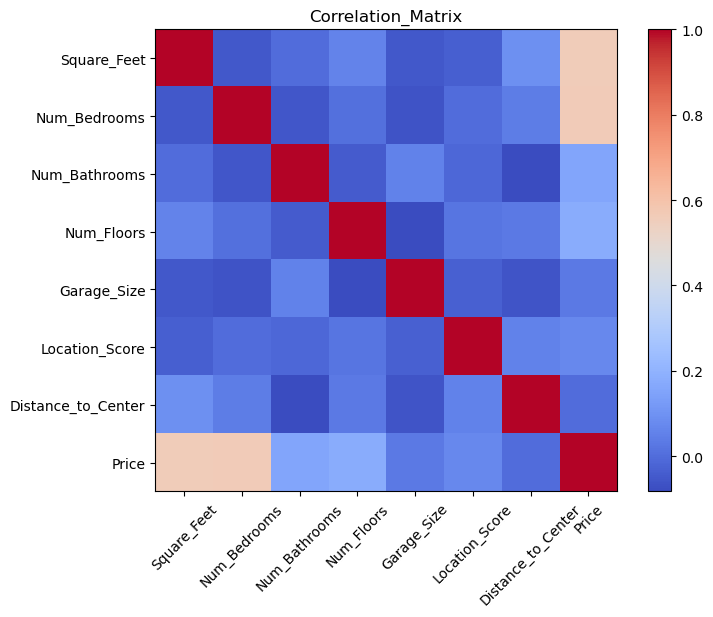

In [13]:
numeric_df = df_house_price.select_dtypes(include=['float64', 'int64'])

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(8,6))
plt.imshow(correlation_matrix,cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=45)
plt.yticks(range(len(correlation_matrix)), correlation_matrix.columns)
plt.title('Correlation_Matrix')
plt.show()


## Step 3: Creating a Multiple Linear Regression (MLR) Model

In this step, we will use Multiple Linear Regression to predict the Price of the house based on the features. We will split the data into a training set and a testing set, fit the model, and evaluate its performance.

Task 3.1: Split the Data into Features and Target
Split the dataset into features (X) and target variable (y).

Task 3.2: Split the Data into Training and Testing Sets
Split the data into training (80%) and testing (20%) sets.

Task 3.3: Train the Multiple Linear Regression Model
Train the Multiple Linear Regression (MLR) model using the training data.

Task 3.4: Visualise the Predicted vs Actual Prices
Create a scatter plot comparing the actual prices and predicted prices for the test set.

Task 3.5: Evaluate the Model
Evaluate the model using Root Mean Squared Error (RMSE) and interpret the results.

**Task 3.1: Split the Data into Features and Target Split the dataset into features (X) and target variable (y).**

In [14]:
x = df_house_price [['Square_Feet', 'Num_Bedrooms', 'Num_Bathrooms','Num_Floors', 'Garage_Size', 'Location_Score', 'Distance_to_Center']]
y = df_house_price ['Price']

**Task 3.2: Split the Data into Training and Testing Sets Split the data into training (80%) and testing (20%) sets.**

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split (x, y, test_size=0.2, random_state=42)
print(f"Training Data: {X_train.shape}, Testing Data: {X_test.shape}")

Training Data: (400, 7), Testing Data: (100, 7)


**Task 3.3: Train the Multiple Linear Regression Model:Train the Multiple Linear Regression (MLR) model using the training data.**

In [35]:
from sklearn.linear_model import LinearRegression
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)

🏃 View run witty_parang_986zn116 at: https://2d0fc43f898c4b4fa153ed44d311104c.pbidedicated.windows.net/webapi/capacities/2d0fc43f-898c-4b4f-a153-ed44d311104c/workloads/ML/ML/Automatic/workspaceid/474d5728-ab24-499a-85de-de48255d6a45/#/experiments/3dddb186-d0e5-4dba-b30b-1912fc5005a8/runs/be804f6f-05ac-4b8e-b321-a8e88e6b13e4
🧪 View experiment at: https://2d0fc43f898c4b4fa153ed44d311104c.pbidedicated.windows.net/webapi/capacities/2d0fc43f-898c-4b4f-a153-ed44d311104c/workloads/ML/ML/Automatic/workspaceid/474d5728-ab24-499a-85de-de48255d6a45/#/experiments/3dddb186-d0e5-4dba-b30b-1912fc5005a8


**Task 3.4: Visualise the Predicted vs Actual Prices.  Create a scatter plot comparing the actual prices and predicted prices for the test set.**

In [58]:
results_df_house_price = pd.DataFrame ({
    'Actual Price': y_test,
    'Predicted Price': y_pred_lr
})

print(results_df_house_price)

     Actual Price  Predicted Price
361   591058.7089    525669.926934
73    667693.0003    668141.051861
374   532377.5802    467168.904743
155   478489.2990    498375.548472
104   730197.4806    691359.973840
..            ...              ...
347   464849.9178    493645.118779
86    572360.6499    643248.170875
75    557752.8374    454235.083741
438   649930.0523    564489.566281
15    523527.9747    456453.859955

[100 rows x 2 columns]


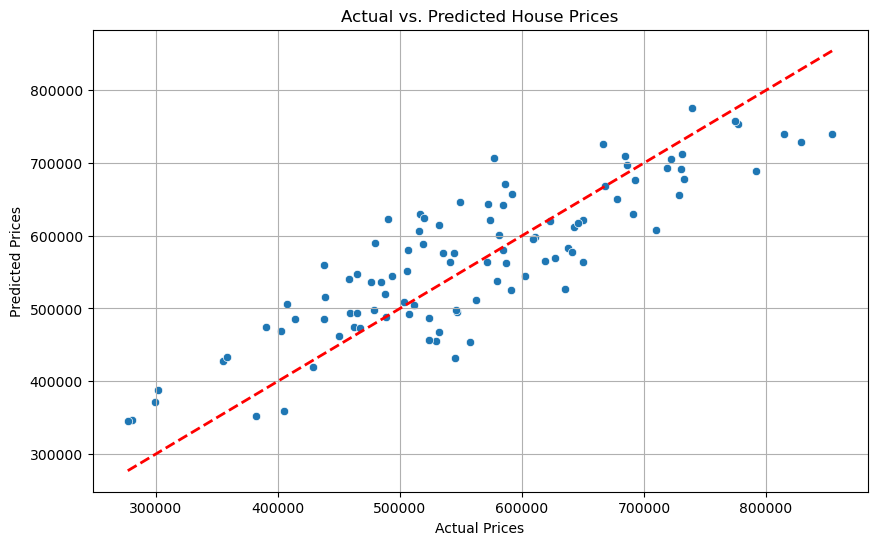

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.scatterplot(x='Actual Price', y='Predicted Price', data=results_df_house_price)

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, linestyle='--')

plt.title('Actual vs. Predicted House Prices')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.grid(True)

plt.show()


**Task 3.5: Evaluate the model using Root Mean Squared Error (RMSE) and interpret the results.**

In [61]:
from sklearn.metrics import mean_squared_error
import numpy as np
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
print(f"Root Mean Squared Error (RMSE) for MLR: {rmse_lr}")

Root Mean Squared Error (RMSE) for MLR: 63952.37599755184


**<mark>Based on the average house price from the dataset is $600,000, then the RMSE is $63,952.  This is roughly around 10% error margin.</mark>**

## Step 4: Compare with Random Forest Regressor

Task 4.1: Train a Random Forest Model
Train a Random Forest Regressor model and evaluate its performance.

Task 4.2: Visualise Actual vs Predicted Prices for Random Forest
Create a scatter plot comparing the actual prices and predicted prices for the Random Forest model.

Task 4.3: Model Comparison
Compare the RMSE values of both the MLR and Random Forest models. Which model performs better?

**Task 4.1: Train a Random Forest Model.  Train a Random Forest Regressor model and evaluate its performance.**

In [62]:
from sklearn.ensemble import RandomForestRegressor
model_rf = RandomForestRegressor(n_estimators=200, random_state=42)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

🏃 View run green_basket_c6cnmx3s at: https://2d0fc43f898c4b4fa153ed44d311104c.pbidedicated.windows.net/webapi/capacities/2d0fc43f-898c-4b4f-a153-ed44d311104c/workloads/ML/ML/Automatic/workspaceid/474d5728-ab24-499a-85de-de48255d6a45/#/experiments/3dddb186-d0e5-4dba-b30b-1912fc5005a8/runs/278b45a5-2c69-4279-a51c-48bf5c3fe988
🧪 View experiment at: https://2d0fc43f898c4b4fa153ed44d311104c.pbidedicated.windows.net/webapi/capacities/2d0fc43f-898c-4b4f-a153-ed44d311104c/workloads/ML/ML/Automatic/workspaceid/474d5728-ab24-499a-85de-de48255d6a45/#/experiments/3dddb186-d0e5-4dba-b30b-1912fc5005a8


In [63]:
results_df_house_price_rf = pd.DataFrame ({
    'Actual Price': y_test,
    'Predicted Price (Random Forest)': y_pred_rf
})

print(results_df_house_price_rf.head())

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print(f"Root Mean Squared Error (RMSE) for Random Forest: {rmse_rf}")

     Actual Price  Predicted Price (Random Forest)
361   591058.7089                    500627.243247
73    667693.0003                    654256.956307
374   532377.5802                    561434.354749
155   478489.2990                    484593.849958
104   730197.4806                    757536.282477
Root Mean Squared Error (RMSE) for Random Forest: 72013.1303207925


<mark>**Random Forest model's predictions are "off" by roughly $72,013. An error margin of 12% as based on the $600,00 average house price.**</mark>

**Task 4.2: Visualise Actual vs Predicted Prices for Random Forest.  Create a scatter plot comparing the actual prices and predicted prices for the Random Forest model.**

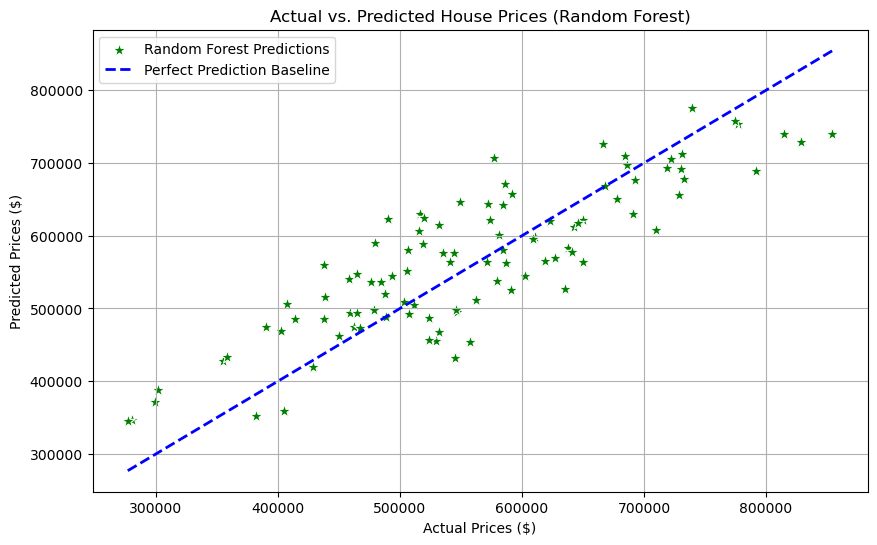

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.scatterplot(x='Actual Price', y='Predicted Price', 
data=results_df_house_price, color='green', marker='*', s=100, label='Random Forest Predictions')


plt.plot([results_df_house_price['Actual Price'].min(), results_df_house_price['Actual Price'].max()], 
[results_df_house_price['Actual Price'].min(), results_df_house_price['Actual Price'].max()], 
color='blue', lw=2, linestyle='--', label='Perfect Prediction Baseline')

plt.title('Actual vs. Predicted House Prices (Random Forest)')
plt.xlabel('Actual Prices ($)')
plt.ylabel('Predicted Prices ($)')
plt.legend()
plt.grid(True)


plt.show()

**Task 4.3: Model Comparison.  Compare the RMSE values of both the MLR and Random Forest models. Which model performs better?**

In [73]:
results_df_house_price = pd.DataFrame({
'Actual Price': y_test,
'Predicted Price (MLR)': y_pred_lr,
'Predicted Price (Random Forest)': y_pred_rf,
})
print(results_df_house_price.head())

     Actual Price  Predicted Price (MLR)  Predicted Price (Random Forest)
361   591058.7089          525669.926934                    500627.243247
73    667693.0003          668141.051861                    654256.956307
374   532377.5802          467168.904743                    561434.354749
155   478489.2990          498375.548472                    484593.849958
104   730197.4806          691359.973840                    757536.282477


<mark>**MLR performs better**</mark>

## Step 5: Conclusion and Insights

Task 5.1: Insights and Recommendations

Based on the RMSE and visualisations, summarise which model performs better and why.

Discuss any improvements that could be made to both models.

In [74]:
print(f"RMSE  for MLR {rmse_lr}")
print(f"RMSE for Random Forest: {rmse_rf}")

RMSE  for MLR 63952.37599755184
RMSE for Random Forest: 72013.1303207925


In [75]:
if rmse_lr < rmse_rf:
    print("The Multiple Linear Regression model performs better based on RMSE.")
else:
    print("The Random Forest model persorms better based on RMSE.")

The Multiple Linear Regression model performs better based on RMSE.


The Multiple Linear Regression (MLR) model performed better than the Random Forest (RF) model for this specific dataset.

The MLR model achieved a lower Root Mean Squared Error (RMSE) of 63,952, compared to the RF model's 72,013. 

While both scatter plots show a strong positive correlation, the MLR predictions appear slightly more tightly clustered around the "Perfect Prediction" baseline.

Relative to a $600,000 house price, the RF model has an approximate error margin of 12%, whereas the MLR model is more accurate at roughly 10.6%.

For Multiple Linear Regression (MLR)
Create New Information: We can combine existing data into more useful categories, like calculating the "Price per Square Foot".

Remove "Odd" Data or Outliers: This model is easily confused by houses that are priced extremely high or low for no clear reason. Removing these outliers helps the model see the "normal" pattern more clearly.

Check for Repeated Info (Multicollinearity): Sometimes two pieces of information, like "Number of Rooms" and "Square Feet," are so similar they confuse the model. We should check if we really need both.

For Random Forest (RF)
Adjusting the "complexity" of the forest by changing the number of trees it uses or how deep each tree is allowed to grow.

Pick the Best Features: If some information (e.g. "Distance to Center") isn't actually helping the model, removing it can make the model focus more on the features that actually matter.

It is better to do a cross-validation. Instead of just testing the model once, we can test it multiple times on different parts of the data to make sure it is truly learning and not just memorizing the answers.


Hi team,

Well done on the code overall. However, I can see that you are not using Markdown cells to provide explanations of your code, methodology, and insights.

I strongly suggest that you add notes throughout the notebook explaining:

The approach you are taking
Why you are using certain functions or techniques
What the output or analysis means

Additionally, after every chart, table, or major output, you should include a short insight section explaining the key findings and business interpretation of the results.

Remember that in data analytics, storytelling and interpretation are just as important as the code itself. The reader should be able to clearly understand your analytical process and conclusions by following both your code and your explanations.

Jose 